## Projektübersicht


In [96]:
# =============================================================================
# Projekt: EMM – Modellierung eines gekoppelten Strom-Wärmesystems#
# Anwendungsfall: Mehrfamilienhaus (MFH)
#
# Ziel des Projekts ist der Vergleich der Auswirkungen unterschiedlicher
# Wärmeverteilungssysteme (Heizkörper vs. Fußbodenheizung) auf ein
# Wärmepumpen-basiertes Energiesystem unter Berücksichtigung verschiedener
# Sanierungsgrade des Gebäudes.
#
# Alle Parameter sind mit Quellenangaben der zugehörigen Excel zu entnehmen.
# =============================================================================

### Gebäude- und Systemannahmen

In [97]:
# =============================================================================
# Gebäude- und Systemannahmen
# =============================================================================
# Mehrfamilienhaus:
# - Beheizte Wohnfläche: 426 m² (siehe Excel-Datei mit Quellen)
# - Anzahl Wohneinheiten: 6
#
# Trinkwarmwasser:
# - Netto-Trinkwarmwasserbedarf: 16,5 kWh/(m²·a)
#
# Elektrisches System:
# - Installierbare PV-Leistung: 13 kWp (PV-Atlas)
#
# Wärmeversorgung:
# - Zentrale Luft-Wasser-Wärmepumpe
# - Geschichteter Pufferwärmespeicher
# - Durchlauferhitzer zur Warmwasserversorgung
# - Simulation in Stundenauflösung
# =============================================================================


### Sanierungsgrade

In [98]:
# =============================================================================
# Sanierungsgrade (Gebäudezustände)
# =============================================================================
# Zur Untersuchung des Einflusses des Gebäudezustands werden drei
# Sanierungsgrade betrachtet, die sich ausschließlich im spezifischen
# Heizwärmebedarf unterscheiden:

# Fall 1: Ist-Zustand (unsaniert)
# - Netto-Heizwärmebedarf: 168,6 kWh/(m²·a)

# Fall 2: Konventionell saniert (Teilsanierung)
# - Netto-Heizwärmebedarf: 82,5 kWh/(m²·a)

# Fall 3: Zukunftsführend saniert (Vollsanierung)
# - Netto-Heizwärmebedarf: 25,0 kWh/(m²·a)
# =============================================================================

### Heizkörper vs. Fußbodenheizung modelieren

In [99]:
# =============================================================================
# Wärmeverteilungssysteme: Heizkörper (HK) vs. Fußbodenheizung (FBH)
# =============================================================================
# Für jeden Sanierungsgrad wird das Energiesystem jeweils mit zwei
# unterschiedlichen Wärmeverteilungssystemen simuliert:

# Heizkörper (HK):
# - Höhere Vorlauftemperaturen (45-55°C)
# - Typisch für Bestandsgebäude
# - Geringere Temperaturspreizung im Wärmespeicher
#
# Fußbodenheizung (FBH):
# - Niedrigere Vorlauftemperaturen (30-35°C)
# - Größere Temperaturspreizung im Wärmespeicher
# - Höhere Effizienz der Wärmepumpe durch niedrigere Temperaturniveaus
#
# Der Wechsel zwischen HK und FBH erfolgt im Modell ausschließlich über:
# - die dafür jeweils geforderte Vorlauftemperatur (T_vorlauf, T_flow)
# - und damit auch die Rücklauftemperatur des Wärmespeichers (T_return)
# =============================================================================

### Heizsystem

![Pufferspeicher mit Durchlauferhitzer](../Images/Pufferspeicher_und_Durchlauferhiztzer.png)


## Code

### Imports

In [100]:
import pypsaheat as ph
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import cm

### Wärmelastgänge - PV-Erzeugung - Außentemperatur - laden

In [101]:
# ------------------------------------------------------------
# Dateien aus dem CLEAN-Ordner laden
# ------------------------------------------------------------
CLEAN = Path("./Input_Data_clean")

# Fall auswählen (nur EINEN aktiv lassen)
lastgang_file = CLEAN / "2026-01-19-Mehrfamilienhaus-Lastprofile_Ist_ZST_clean.csv"
# lastgang_file = CLEAN / "2026-01-19-Mehrfamilienhaus-Lastprofile_konventionell_clean.csv"
# lastgang_file = CLEAN / "2026-01-19-Mehrfamilienhaus-Lastprofile_zukunftsfuehrend_clean.csv"

# Version automatisch aus Dateiname ableiten lassen
lf = lastgang_file.name.lower()
if "ist_zst" in lf:
    lastgang_version = "Ist_ZST"
elif "konventionell" in lf:
    lastgang_version = "konventionell"
elif "zukunft" in lf:
    lastgang_version = "zukunftsfuehrend"
else:
    lastgang_version = "unknown"

# CLEAN-Lastgang hat schon eine 'time' Spalte -> direkt parsen
df = pd.read_csv(lastgang_file, parse_dates=["time"])
df = df.set_index("time").sort_index()



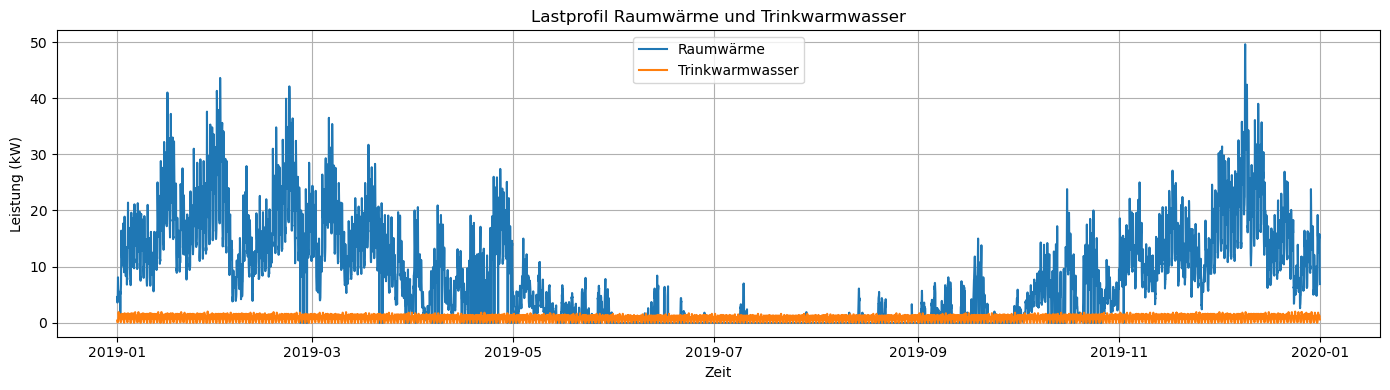

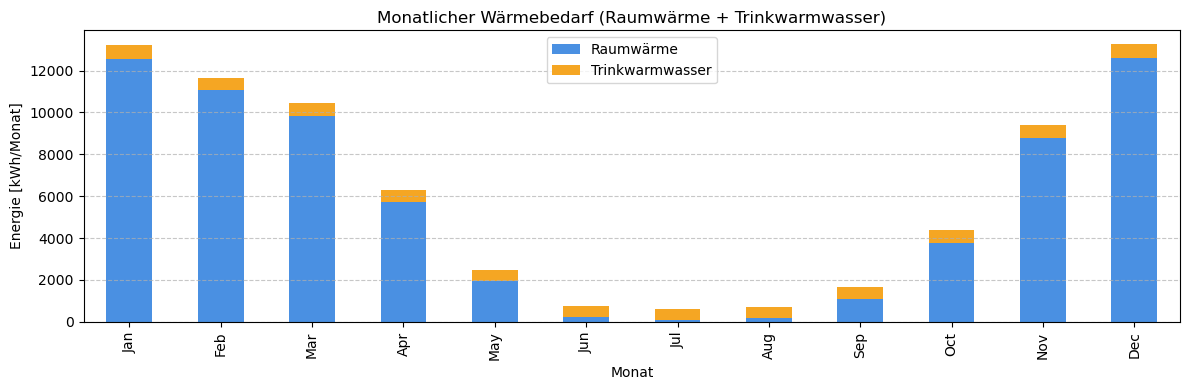

In [102]:
# ------------------------------------------------------------
# Plot der Lasten erstellen
# ------------------------------------------------------------

plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Raumwaerme_(kW)"], label="Raumwärme")
plt.plot(df.index, df["Trinkwarmwasser_(kW)"], label="Trinkwarmwasser")

plt.legend()
plt.title("Lastprofil Raumwärme und Trinkwarmwasser")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Monats-Balkendiagramm: Raumwärme + Trinkwarmwasser
# ------------------------------------------------------------

# Monatsenergie berechnen (kWh/Monat bei 1h-Zeitschritt)
monthly_heat = df.resample("ME")[[
    "Raumwaerme_(kW)",
    "Trinkwarmwasser_(kW)"
]].sum()

# Monatsnamen hübsch
monthly_heat.index = monthly_heat.index.strftime("%b")

# Plot
ax = monthly_heat.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 4),
    color=["#4A90E2", "#F5A623"]  # Blau = Raumwärme, Orange = TWW
)

ax.set_title("Monatlicher Wärmebedarf (Raumwärme + Trinkwarmwasser)")
ax.set_xlabel("Monat")
ax.set_ylabel("Energie [kWh/Monat]")
ax.legend(["Raumwärme", "Trinkwarmwasser"])
ax.grid(axis="y", alpha=0.7, linestyle="--")

plt.tight_layout()
plt.show()

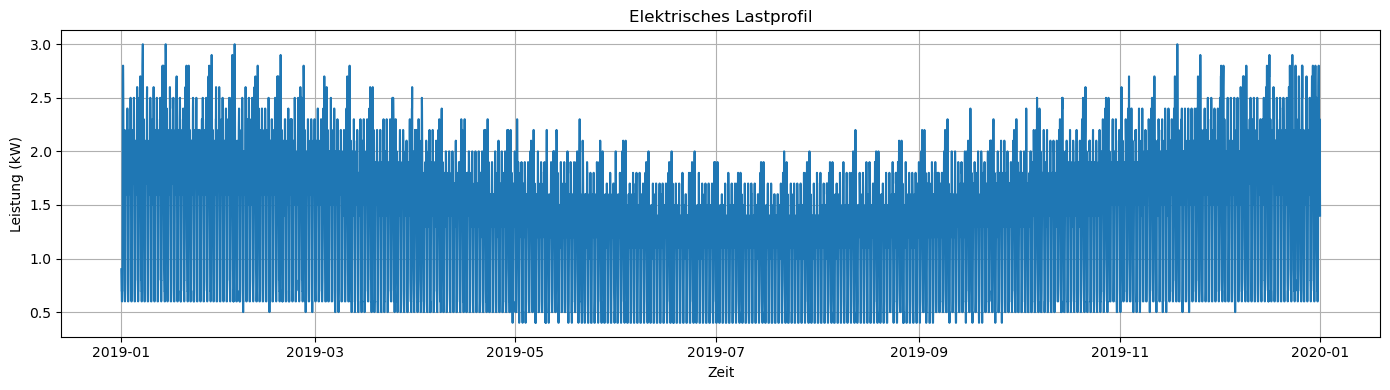

In [103]:
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Strom_gesamt_(kW)"], label="Haushaltsstrom (ohne DLE)")
plt.title("Elektrisches Lastprofil")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [104]:
# ------------------------------------------------------------
# PV clean laden
# ------------------------------------------------------------
pv = pd.read_csv(CLEAN / "pv_clean.csv", parse_dates=["time"])
pv = pv.set_index("time").sort_index()

# (optional) clip, falls Mini-Ausreißer
pv["pv_electricity"] = pv["pv_electricity"].astype(float).clip(lower=0)

# ------------------------------------------------------------
# Weather clean laden
# ------------------------------------------------------------
weather = pd.read_csv(CLEAN / "weather_clean.csv", parse_dates=["time"])
weather = weather.set_index("time").sort_index()
weather["T_outdoor"] = weather["T_outdoor"].astype(float)
T_outdoor = weather["T_outdoor"]


print("PV Index:", pv.index.min(), "->", pv.index.max(), "len:", len(pv))
print("Weather Index:", weather.index.min(), "->", weather.index.max(), "len:", len(weather))


PV Index: 2019-01-01 01:00:00 -> 2020-01-01 00:00:00 len: 8760
Weather Index: 2019-01-01 01:00:00 -> 2020-01-01 00:00:00 len: 8760


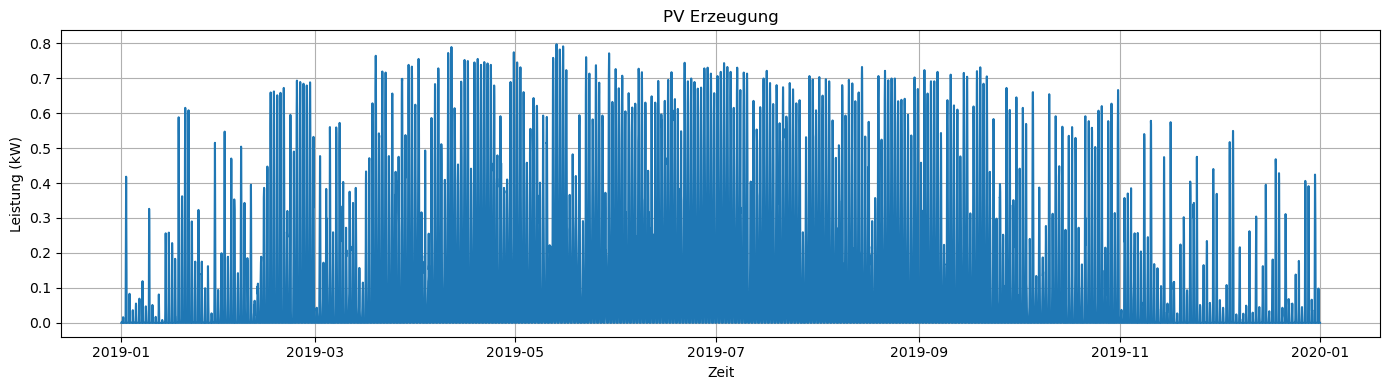

In [105]:
# ------------------------------------------------------------
# Erzeugungsprofil PV plotten
# ------------------------------------------------------------
plt.figure(figsize=(14,4))
plt.plot(pv.index, pv["pv_electricity"], label="PV (kW)")
plt.title("PV Erzeugung")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()

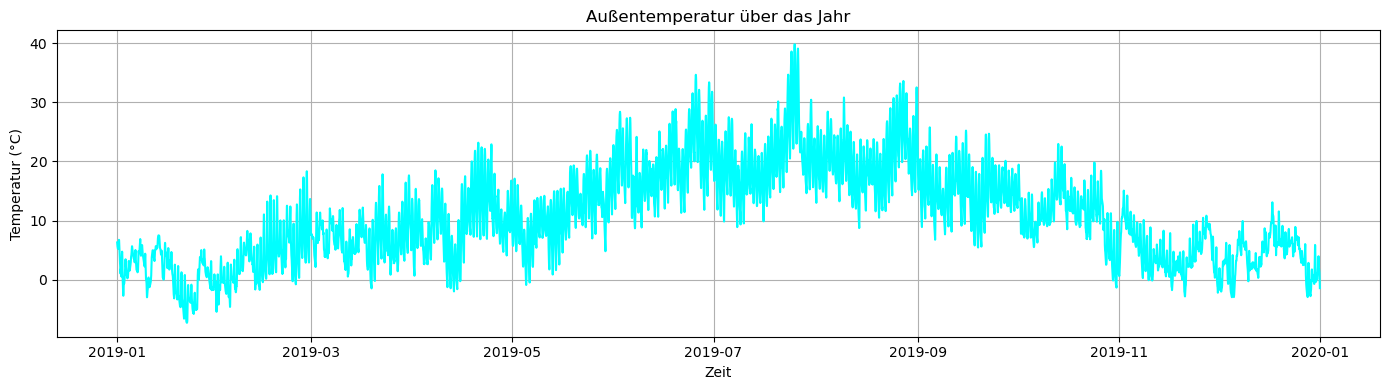

In [106]:
# -------------------------------------------
# Außentemperatur plotten
# -------------------------------------------
plt.figure(figsize=(14,4))
plt.plot(weather.index, weather["T_outdoor"], label="Außentemperatur (°C)", color="cyan")

plt.title("Außentemperatur über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [107]:
# ------------------------------------------------------------
# Zeitreihen-Synchronisation (PV, Außentemperatur) auf Modellzeitachse
# - Vereinheitlicht Zeitindex auf snapshots=df.index
# - Aggregiert doppelte Zeitstempel (z.B. DST) durch Mittelung
# - Korrigiert ggf. einen 1h-Startversatz zwischen Datensätzen
# - Entfernt verbleibende Einzel-NaNs konsistent aus allen Zeitreihen (ohne Imputation)
# ------------------------------------------------------------

snapshots = df.index

def align_series_to_snapshots(s: pd.Series, snapshots: pd.DatetimeIndex):
    s = s.copy()
    s.index = pd.to_datetime(s.index)

    # 1) Doppelte Zeitstempel (z.B. DST) aggregieren
    if s.index.duplicated().any():
        s = s.groupby(level=0).mean()

    # 2) Optionalen 1h-Offset korrigieren
    offset = s.index.min() - snapshots.min()
    if offset == pd.Timedelta(hours=1):
        s.index = s.index - pd.Timedelta(hours=1)
    elif offset == pd.Timedelta(hours=-1):
        s.index = s.index + pd.Timedelta(hours=1)

    # 3) Auf Modellzeitachse bringen
    return s.reindex(snapshots)

# --- PV & Weather als Series rausziehen ---
pv_pu_raw = pv["pv_electricity"].astype(float).clip(lower=0)
T_outdoor_raw = weather["T_outdoor"].astype(float)

# --- Align ---
pv_pu = align_series_to_snapshots(pv_pu_raw, snapshots)
T_outdoor = align_series_to_snapshots(T_outdoor_raw, snapshots)

# --- Konsistenz: Stunden mit NaN entfernen (keine Daten-Ersetzung) ---
valid = pv_pu.notna() & T_outdoor.notna()

if (~valid).any():
    # optional: eine kurze Info
    print(f"Zeitreihen-Abgleich: {int((~valid).sum())} Zeitschritt(e) entfernt (fehlende Werte nach Reindex).")

df = df.loc[valid]
pv_pu = pv_pu.loc[valid]
T_outdoor = T_outdoor.loc[valid]

# snapshots aktualisieren
snapshots = df.index


Zeitreihen-Abgleich: 1 Zeitschritt(e) entfernt (fehlende Werte nach Reindex).


### Vorlauftemperatur & Rücklauf (HK/FBH)

In [108]:
# ------------------------------------------------------------
# Heizkörper vs. Fußbodenheizung über Heizkurve (flow_temperature)
# ------------------------------------------------------------

# Flag: True = Heizkörper, False = Fußbodenheizung
use_radiators = False

# HK T_vorlauf = 45 - 55 °C; FBH T_Vorlauf = 30-35 °C
T_vorlauf = 51.0 if use_radiators else 33.0         # 51 °C bei 0°C ; bzw 33 bei 0°C (nach Quelle - 30°C bei -10°C - 55° bei -10°C)
T_gradient = 6/15 if use_radiators else 3/15        # wie stark die Vorlauftemperatur mit der Außentemp. steigt/fällt

# Heizkurve berechnen (PyPSA_heat-Funktion)
T_flow = ph.physics.flow_temperature(T_vorlauf, T_gradient, T_outdoor)

# sicherstellen: exakt df.index
T_flow = pd.Series(np.asarray(T_flow, dtype=float), index=df.index)


heating_cutoff = 15.0                          # °C Außentemperatur, ab der nicht mehr geheizt wird
heat_on = T_outdoor <= heating_cutoff
T_flow_min = 45 if use_radiators else 30       # Mindestvorlauftemperatur
T_flow = T_flow.clip(lower=T_flow_min)
T_flow = T_flow.where(heat_on, T_flow_min)

#Rücklauftemperatur vorgeben
delta_T = 10.0 if use_radiators else 5.0       # FBH hat geringere Rücklauftemperatur ~ %°C
store_T_return  = T_flow_min - delta_T          # °C Rücklauftemperatur 35 HK und 25 FBH

store_T_return



25.0

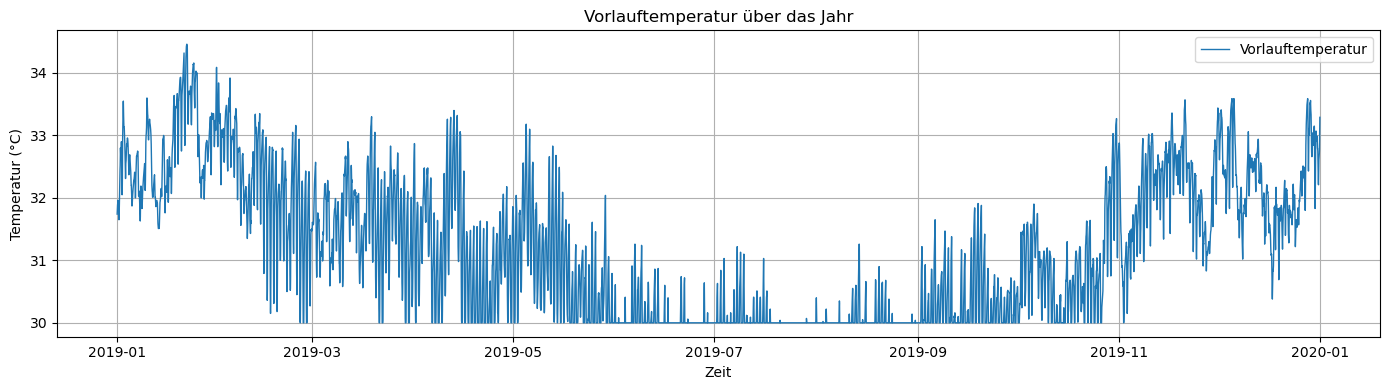

In [109]:
plt.figure(figsize=(14,4))
plt.plot(df.index, T_flow, label="Vorlauftemperatur", linewidth=1)

plt.title("Vorlauftemperatur über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




### Komponentenparameter & Kosten

In [110]:
# --------------------------------
# Parametrisierung der Komponenten
# --------------------------------

#Strom Daten
grid_power      =   87        # kW Hausanschluss Leistung
grid_cost       =   0.372     # €/kWh Kosten für Netzstrombezug

interest_rate = 0.02

# PV - Daten
pv_invest       =   731     # €/kWp (einmalig)
pv_lifetime     =   20      # Jahre
PV_power        =   13      # kWp
feed_in_tariff  =   -0.0778   # €/kWh
pv_annuity = pv_invest * ((1+interest_rate)**pv_lifetime) * interest_rate / ((1+interest_rate)**pv_lifetime - 1)


#Batterie Daten
battery_invest           = 500     #€/kWh
battery_lifetime         = 20      # Jahre
battery_annuity = battery_invest * ((1+interest_rate)**battery_lifetime) * interest_rate / ((1+interest_rate)**battery_lifetime - 1)


#Wärmespeicher Daten
store_height    =   1      #m
store_base      =   0.5    #m²
# Volumen = store_base * store_height = 1.52 m³
store_u_wall    =   0.36      #W/(m²*K)
store_T_layers  =   [55, 53, 51, 49, 47, 45, 43, 41, 39] if use_radiators else [35, 33, 31, 29]  #°C Temperaturschichten;
store_invest    =   1690      # €/kWh
store_lifetime  =   20       # Jahre
store_annuity   = store_invest * ((1+interest_rate)**store_lifetime) * interest_rate / ((1+interest_rate)**store_lifetime - 1)

# Heizstab
HE_power        =   9       # Heizstab-Nennleistung (kW)

# Wärmepumpe
HP_power        =    40     # WP-Nennleistung (kW_th)


### Energiesystem

In [112]:
# ------------------------------------------------------------
# Allgemeine Einstellungen des Networks
# ------------------------------------------------------------

n = ph.HeatNetwork()
n.set_snapshots(df.index)


# ------------------------------------------------------------
# Modellierung des Energiesystems
# ------------------------------------------------------------
# Busse
n.add("Bus", "electricity_grid")
n.add("Bus", "electricity_infeed")

# Grid import
n.add("Generator", "grid_import",
      bus="electricity_grid",
      p_nom=grid_power,
      marginal_cost=grid_cost)

# PV generation
n.add("Generator", "pv_generation",
      bus="electricity_infeed",
      p_nom=PV_power,
      p_max_pu=pv_pu.values,
      capital_cost=pv_annuity)

# Strom einspeisen - export Generator
n.add("Generator", "pv_infeed",
      bus="electricity_infeed",
      p_nom=PV_power,                   # begrenzt die max. Exportleistung
      marginal_cost=feed_in_tariff,
      sign=-1)

# Link PV -> Hausnetz
n.add("Link", "electricity_link",
      bus0="electricity_infeed",
      bus1="electricity_grid",
      p_nom=PV_power,
      efficiency=1.0)

# Wärmespeicher
n.add("HeatStore", "hs_mfh",
      constant="temperature",
      height=store_height,
      base=store_base,
      T_layer=store_T_layers,
      T_return=store_T_return,
      V_initial=[0]*len(store_T_layers),
      cyclic=True,
      T_amb=18.0,
      U_wall=store_u_wall)

# Wärmepumpe (FIX p_nom)
n.add("HeatPump", "hp_mfh",
      bus0="electricity_grid",
      heat_store="hs_mfh",
      p_nom=HP_power,
      T_source=T_outdoor,
      T_max=65,
      heat_source="air")

# Heizstab
n.add("HeatingElement", "backup_heater",
      bus0="electricity_grid",
      heat_store="hs_mfh",
      p_nom=HE_power,
      efficiency=0.95)

# Durchlauferhitzer: DHW als elektrische Last (η ~ 1)
eta_dlhe = 0.98                                                 # Wirkungsgrad Durchlauferhitzer
n.add("Load", "el_dhw_dlhe",
      bus="electricity_grid",
      p_set=(df["Trinkwarmwasser_(kW)"].values / eta_dlhe))


# Elektrische Haushaltslast
n.add("Load", "el_demand",
      bus="electricity_grid",
      p_set=df["Strom_gesamt_(kW)"].values)


n.add("HeatLoad", "Raumwaerme",
      heat_store="hs_mfh",
      p_set=df["Raumwaerme_(kW)"].to_numpy(),
      T_demand=T_flow)



C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dty

In [124]:
# ------------------------------------------------------------
# Check: wird T_flow als zeitabhängiges T_demand im Modell verwendet?
# - prüfen ob update von Pypsaheat geklappt hat
# ------------------------------------------------------------
td_static = n.heat_loads.loc["Raumwaerme", "T_demand"]

td_ts = None
if hasattr(n, "heat_loads_t") and "T_demand" in n.heat_loads_t:
    td_ts = n.heat_loads_t["T_demand"]["Raumwaerme"]

print(f"T_demand (static param): {float(td_static):.1f} °C")

if td_ts is None:
    print("T_demand (time series): nicht vorhanden (noch nicht aufgebaut)")
else:
    print(f"T_demand (time series): min={float(td_ts.min()):.2f} °C, max={float(td_ts.max()):.2f} °C")
    print(f"T_demand == T_flow: {np.allclose(td_ts.values, T_flow.values)}")



T_demand (static param): 50.0 °C
T_demand (time series): min=30.00 °C, max=34.46 °C
T_demand == T_flow: True


In [114]:

# ------------------------------------------------------------------
# System lösen
n.optimize(solver_name="gurobi")
# ------------------------------------------------------------------


Index(['electricity_grid', 'electricity_infeed'], dtype='object', name='Bus')
Index(['electricity_link'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2694931


INFO:gurobipy:Set parameter LicenseID to value 2694931


...

Solved in 50830 iterations and 0.73 seconds (0.93 work units)


INFO:gurobipy:Solved in 50830 iterations and 0.73 seconds (0.93 work units)


Optimal objective  9.834055726e+03


INFO:gurobipy:Optimal objective  9.834055726e+03
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 148903 primals, 306565 duals
Objective: 9.83e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, HeatStore-hs_mfh-fix-volume-upper, HeatStore-hs_mfh-fix-volume-lower, HeatStore-hs_mfh-layer_balance, HeatStore-hs_mfh-internal-lower, HeatingElement-backup_heater-fix-p-lower, HeatingElement-backup_heater-fix-p-upper, HeatPump-hp_mfh-fix-p-lower, HeatPump-hp_mfh-fix-p-upper, HeatPump-hp_mfh-fix-p-layer-lower, HeatPump-hp_mfh-fix-p-layer-upper were not assigned to the network.


PyPSA Heat Network
Components:
 - Bus: 2
 - Generator: 3
 - Link: 1
 - Load: 2
 - HeatLoad: 1
 - HeatPump: 1
 - HeatStore: 1
 - HeatingElement: 1
Snapshots: 8759

### Energiesystem: Ergebnisse & Kennzahlen

#### Wärmespeicher


================ Wärmespeicher Summary ================
HS: hs_mfh | Vtot=0.500 m³ (H=1.00 m, A=0.500 m²)
T_layer: [29, 31, 33, 35] °C | T_return: 25 °C

        Schicht  Volumen über Jahr [m³·h] Anteil an Jahresnutzung [%] Aktive Stunden [h/a] (V > 0) Volumen über Jahr [m³]
T_return (25°C)               2500.903270                       57,10                      6790,00                 2500,9
           29°C                  2.722403                        0,06                      1498,00                    2,7
           31°C                 66.346427                        1,51                      2103,00                   66,3
           33°C                522.026254                       11,92                      3766,00                  522,0
           35°C               1287.501646                       29,40                      5936,00                 1287,5

Sanity: Summe Anteile = 100.00%


C:\Users\sarah\AppData\Local\Temp\ipykernel_112676\2477955150.py:40: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



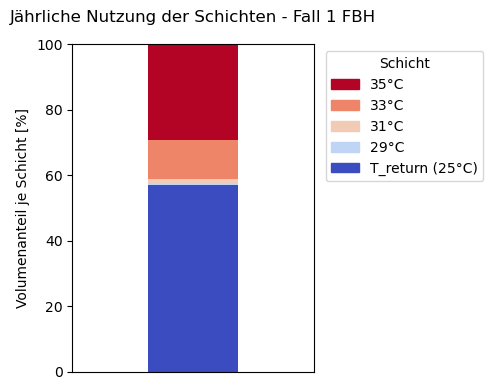

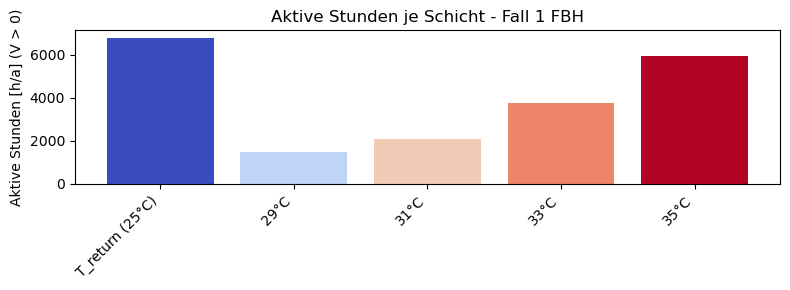

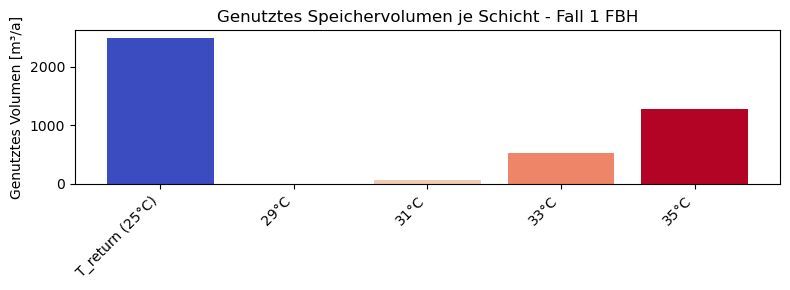

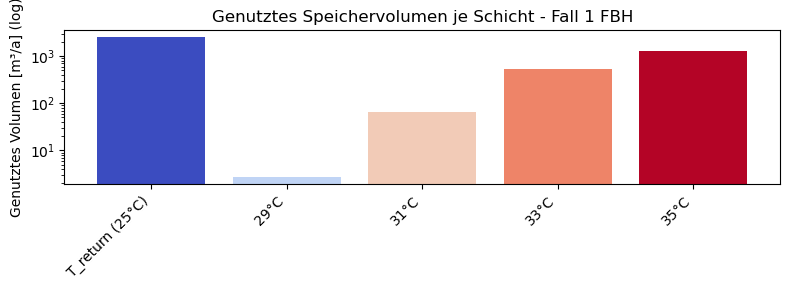

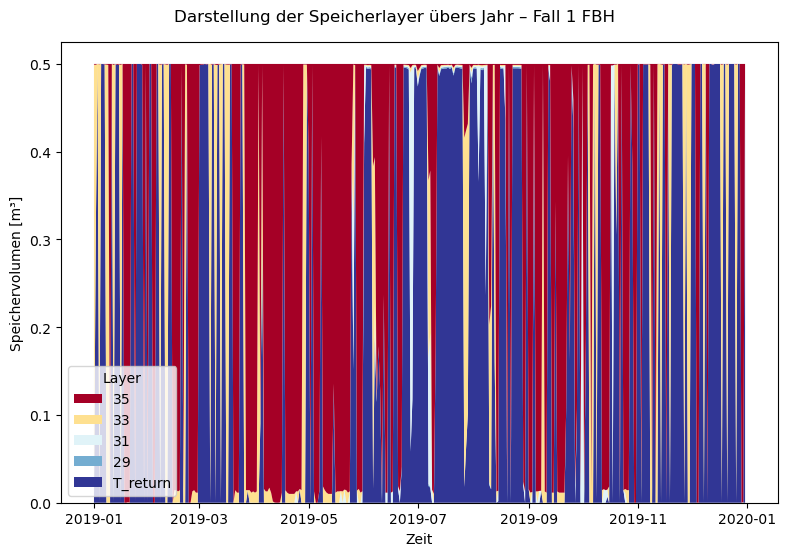

HeatStores vorhanden: ['hs_mfh']

hs_mfh Parameter:
attribute
constant          temperature
type                         
carrier                      
height                    1.0
base                      0.5
N_layer                     3
T_layer      [35, 33, 31, 29]
T_amb                    18.0
T_return                 25.0
T_initial                [20]
V_initial        [0, 0, 0, 0]
cyclic                   True
U_wall                   0.36
T_max                      95
Name: hs_mfh, dtype: object

V_layer time series vorhanden?: False
T_layer time series vorhanden?: False


In [115]:
hs = "hs_mfh"

# ---------- Parameter ----------
H = float(n.heat_stores.loc[hs, "height"])
A = float(n.heat_stores.loc[hs, "base"])
Vtot = H * A                                                     # Gesamt Speichervolumen

T_layers = np.array(n.heat_stores.loc[hs, "T_layer"], float)
T_return = float(n.heat_stores.loc[hs, "T_return"])

V_layers = n.heat_stores_t["V_layer"][hs]
V_return_ts = (Vtot - V_layers.sum(axis=1)).clip(lower=0.0)

# kalt -> heiß
order = np.argsort(T_layers)
T_sorted = T_layers[order]
V_sorted = V_layers.iloc[:, order]

# ---------- Kennzahlen ----------

year_V_layers = V_sorted.sum(axis=0).values      # m³·h
year_V_return = V_return_ts.sum()                # m³·h

year_total = year_V_layers.sum() + year_V_return

share_layers_pct = year_V_layers / year_total * 100
share_return_pct = year_V_return / year_total * 100

active_layers_h = (V_sorted > 0).sum(axis=0)              # Anzahl aktiver Schichten; z.B.: "Schicht X °C war 4200 Stunden aktiv"
active_return_h = int((V_return_ts > 0).sum())              # Stunden des Rücklaufs im Jahr aktiv; aktiv = V>0 !

labels = [f"T_return ({T_return:.0f}°C)"] + [f"{t:.0f}°C" for t in T_sorted]

year_m3h = np.r_[year_V_return, year_V_layers]
year_V = np.r_[year_V_return, year_V_layers]
share_pct = np.r_[share_return_pct, share_layers_pct]
active_h = np.r_[active_return_h, active_layers_h]

# ---------- Farben kalt->heiß ----------
cmap = cm.get_cmap("coolwarm")
temps_for_colors = np.r_[T_return, T_sorted]
norm = (temps_for_colors - temps_for_colors.min()) / (temps_for_colors.max() - temps_for_colors.min() + 1e-12)
colors = cmap(norm)

# ---------- Tabelle mit Daten  ----------
df = pd.DataFrame({
    "Schicht": labels,
    "Volumen über Jahr [m³·h]": year_m3h,
    "Anteil an Jahresnutzung [%]": share_pct,
    "Aktive Stunden [h/a] (V > 0)": active_h
})

df_print = df.copy()
df_print["Volumen über Jahr [m³]"] = df_print["Volumen über Jahr [m³·h]"].map(lambda x: f"{x:.1f}".replace(".", ","))
df_print["Anteil an Jahresnutzung [%]"] = df_print["Anteil an Jahresnutzung [%]"].map(lambda x: f"{x:.2f}".replace(".", ","))
df_print["Aktive Stunden [h/a] (V > 0)"] = df_print["Aktive Stunden [h/a] (V > 0)"].map(lambda x: f"{x:.2f}".replace(".", ","))


print("\n================ Wärmespeicher Summary ================")
print(f"HS: {hs} | Vtot={Vtot:.3f} m³ (H={H:.2f} m, A={A:.3f} m²)")
print(f"T_layer: {list(map(int, T_sorted))} °C | T_return: {T_return:.0f} °C")
print("======================================================\n")
print(df_print.to_string(index=False))

print(f"\nSanity: Summe Anteile = {df['Anteil an Jahresnutzung [%]'].sum():.2f}%")


# ---------- Plot 1: Jahresauswertung gestapelt (Volumenanteile) ----------
fig, ax = plt.subplots(figsize=(5,4))
bottom = 0.0
for lab, val, col in zip(labels, share_pct, colors):
    ax.bar(0, val, bottom=bottom, color=col, width=0.6, edgecolor="none")
    bottom += val

ax.set_xlim(-0.8, 0.8)
ax.set_xticks([])
ax.set_ylim(0, 100)
ax.set_ylabel("Volumenanteil je Schicht [%]")
handles = [plt.Rectangle((0,0),1,1,color=c) for c in colors[::-1]]
ax.legend(handles, labels[::-1], title="Schicht", bbox_to_anchor=(1.02,1), loc="upper left")
plt.title("Jährliche Nutzung der Schichten - Fall 1 FBH", pad=16)
plt.tight_layout()
plt.show()

# ---------- Plot 2: Aktivität je Schicht ----------
plt.figure(figsize=(8,3))
plt.bar(labels, active_h, color=colors, edgecolor="none")
plt.ylabel("Aktive Stunden [h/a] (V > 0)")
plt.title("Aktive Stunden je Schicht - Fall 1 FBH")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---------- Plot 2.1: genutztes Volumen je Schicht im jahr ----------
plt.figure(figsize=(8,3))
plt.bar(labels, year_V, color=colors, edgecolor="none")
plt.ylabel("Genutztes Volumen [m³/a]")
plt.title("Genutztes Speichervolumen je Schicht - Fall 1 FBH")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---------- Plot: genutztes Volumen je Schicht (log y) ----------
eps = 1e-3  # kleines Volumen für log-Darstellung
year_V_plot = np.maximum(year_V, eps)

plt.figure(figsize=(8,3))
plt.bar(labels, year_V_plot, color=colors, edgecolor="none")
plt.yscale("log")
plt.ylabel("Genutztes Volumen [m³/a] (log)")
plt.title("Genutztes Speichervolumen je Schicht - Fall 1 FBH")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ---------- Plot 3: pypsaheat Zeitplot (dein Standard) ----------
sns_to_plot = n.snapshots[::24]
ph.plot.plot_stratified_heat_store(n, hs=hs, sns=sns_to_plot)

fig = plt.gcf()
ax = plt.gca()

fig.suptitle(
    "Darstellung der Speicherlayer übers Jahr – Fall 1 FBH",
    y=0.92
)

ax.set_ylabel("Speichervolumen [m³]")
ax.set_xlabel("Zeit")

fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()



# ============================
# HeatStore-Daten abfragen
# ============================
print("HeatStores vorhanden:",
      getattr(n, "heat_stores", pd.DataFrame()).index.tolist())

if "hs_mfh" in getattr(n, "heat_stores", pd.DataFrame()).index:
    print("\nhs_mfh Parameter:")
    print(n.heat_stores.loc["hs_mfh"])

    print("\nV_layer time series vorhanden?:",
          hasattr(getattr(n, "heat_stores_t", None), "V_layer")
          and "hs_mfh" in n.heat_stores_t.V_layer.columns)

    print("T_layer time series vorhanden?:",
          hasattr(getattr(n, "heat_stores_t", None), "T_layer")
          and "hs_mfh" in n.heat_stores_t.T_layer.columns)
else:
    print("hs_mfh ist nicht im Network gelandet.")


#### Wärmepumpe – Betrieb, COP & JAZ


Wärmepumpe – Auswertung (hp_mfh)


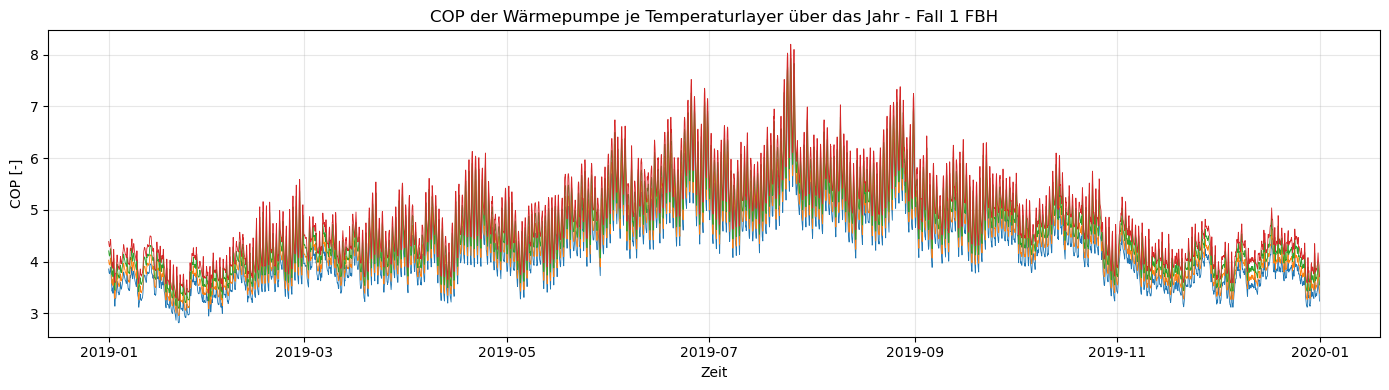


--- Auslegung ---
Thermische Nennleistung p_nom: 40.00 kW_th

--- COP Kennzahlen (physikalisch = p_heat/p_elec) ---
COP Mittelwert: 4.36
COP Median:     4.17
COP Minimum:    2.82
COP Maximum:    8.17

--- Jahresenergien ---
WP Stromverbrauch: 17499.19 kWh_el/a
WP Wärmeerzeugung: 67973.67 kWh_th/a

--- JAZ ---
JAZ_HP (Q_hp / E_hp): 3.884


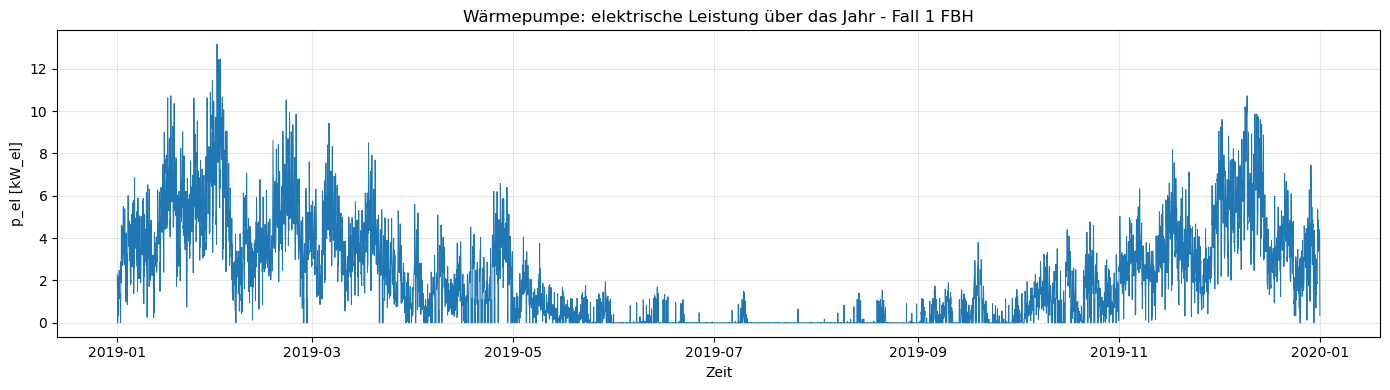

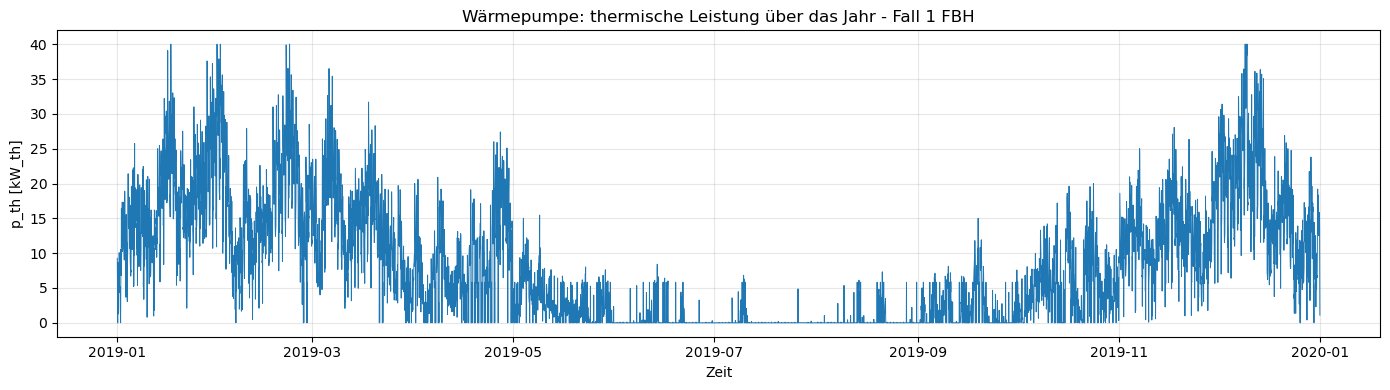

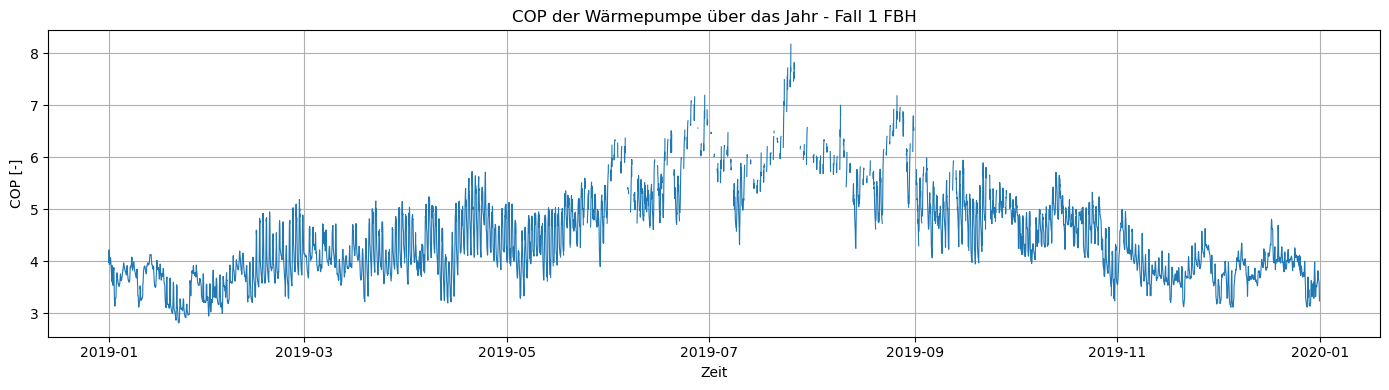

Index(['bus0', 'heat_store', 'type', 'carrier', 'p_nom', 'm_nom', 'T_source',
       'T_nom', 'T_max', 'COP_model', 'heat_source'],
      dtype='object', name='attribute')
attribute
bus0           electricity_grid
heat_store               hs_mfh
type                           
carrier                        
p_nom                      40.0
m_nom                       0.0
T_source                    0.0
T_nom                      60.0
T_max                      65.0
COP_model                   0.0
heat_source                 air
Name: hp_mfh, dtype: object


In [116]:
# ============================================================
# Wärmepumpe (hp_mfh): Kennzahlen, COP-Verlauf, JAZ
# ============================================================

hp_name = "hp_mfh"
hp_df = n.df("HeatPump")        # Tabelle Parameter HP
hp_t  = n.pnl("HeatPump")       # Zeitreihen-Container pro Std. für HP (p_heat, p_elec, COP)

print("\n====================================")
print(f"Wärmepumpe – Auswertung ({hp_name})")
print("====================================")

# --- Modellergebnisse der WP  ---
cop_model  = hp_t["COP"][hp_name]         # kommt aus unserem Model und kann mehere     Temperaturschichten bedienen
p_el_model = hp_t["p_elec"][hp_name]      # p_el_model = elektrische Leistung der WP
p_th_model = hp_t["p_heat"][hp_name]      # p_th_model = thermische Leistung der WP

# ============================================================
# Extra Plot: COP je Temperaturschicht darstellen
# ============================================================

plt.figure(figsize=(14,4))

if isinstance(cop_model, pd.DataFrame):
    # Mehrere Temperaturlayer → jede Spalte wird eine Linie
    plt.plot(cop_model.index, cop_model.values, linewidth=0.6)
    plt.title("COP der Wärmepumpe je Temperaturlayer über das Jahr - Fall 1 FBH")
else:
    # Nur ein Layer
    plt.plot(cop_model.index, cop_model.values, linewidth=0.8)
    plt.title("COP der Wärmepumpe über das Jahr - Fall 1 FBH")

plt.xlabel("Zeit")
plt.ylabel("COP [-]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# ============================================================


# --- Zeitindex (für Plot & Resample) ---
time_index = n.snapshots


p_th_total = p_th_model.sum(axis=1) if isinstance(p_th_model, pd.DataFrame) else p_th_model
p_el_total = p_el_model.sum(axis=1) if isinstance(p_el_model, pd.DataFrame) else p_el_model

# optional: Modell-COP als Mittel (nur Info)
cop_model_mean = cop_model.mean(axis=1) if isinstance(cop_model, pd.DataFrame) else cop_model

p_el_ts = pd.Series(np.asarray(p_el_total, dtype=float), index=time_index)
p_th_ts = pd.Series(np.asarray(p_th_total, dtype=float), index=time_index)
cop_model_ts = pd.Series(np.asarray(cop_model_mean, dtype=float), index=time_index)

# COP berechnung aus Q/P
cop_phys_ts = p_th_ts / p_el_ts.replace(0, np.nan)

# --- Auslegung ---
P_th_nom_val = float(hp_df.loc[hp_name, "p_nom"]) if "p_nom" in hp_df.columns else None
print("\n--- Auslegung ---")
if P_th_nom_val is not None:
    print(f"Thermische Nennleistung p_nom: {P_th_nom_val:.2f} kW_th")

# --- Kennzahlen (COP der WP) ---
COP_mean   = float(np.nanmean(cop_phys_ts.values))      # Durchschnittlicher Betriebs-COP
COP_median = float(np.nanmedian(cop_phys_ts.values))    # Median-Betriebs-COP
COP_min    = float(np.nanmin(cop_phys_ts.values))       # Schlechtester Betriebszustand
COP_max    = float(np.nanmax(cop_phys_ts.values))       # Bester Betriebszustand

print("\n--- COP Kennzahlen (physikalisch = p_heat/p_elec) ---")
print(f"COP Mittelwert: {COP_mean:.2f}")
print(f"COP Median:     {COP_median:.2f}")
print(f"COP Minimum:    {COP_min:.2f}")
print(f"COP Maximum:    {COP_max:.2f}")

# --- Jahresenergien ---
E_hp = float(np.nansum(p_el_ts.values))  # kWh_el/a
Q_hp = float(np.nansum(p_th_ts.values))  # kWh_th/a

print("\n--- Jahresenergien ---")
print(f"WP Stromverbrauch: {E_hp:.2f} kWh_el/a")
print(f"WP Wärmeerzeugung: {Q_hp:.2f} kWh_th/a")

# --- JAZ Berechnung ---
print("\n--- JAZ ---")
JAZ_hp = (Q_hp / E_hp) if E_hp > 0 else np.nan
print(f"JAZ_HP (Q_hp / E_hp): {JAZ_hp:.3f}")


# ============================================================
# --- Ergebnis Plots:  ---
# ============================================================
# Wärmepumpe: elektrische Leistung über das Jahr
plt.figure(figsize=(14,4))
plt.plot(p_el_ts.index, p_el_ts.values, linewidth=0.7)
plt.title("Wärmepumpe: elektrische Leistung über das Jahr - Fall 1 FBH")
plt.xlabel("Zeit")
plt.ylabel("p_el [kW_el]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wärmepumpe: thermische Leistung über das Jahr
plt.figure(figsize=(14,4))
plt.plot(p_th_ts.index, p_th_ts.values, linewidth=0.7)
plt.title("Wärmepumpe: thermische Leistung über das Jahr - Fall 1 FBH")
plt.xlabel("Zeit")
plt.ylabel("p_th [kW_th]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wärmepumpe: Betriebs COP über das Jahr
plt.figure(figsize=(14,4))
plt.plot(cop_phys_ts.index, cop_phys_ts.values, linewidth=0.8, label="COP phys (Q/P)")
plt.title("COP der Wärmepumpe über das Jahr - Fall 1 FBH")
plt.xlabel("Zeit")
plt.ylabel("COP [-]")
plt.grid(True)
plt.tight_layout()
plt.show()

hp_df = n.df("HeatPump")
print(hp_df.columns)
print(hp_df.loc["hp_mfh"])


#### Heizstab – Betrieb & Jahresenergie

heating_elements_t keys: ['p', 'p_heat', 'p_elec']

--- Peaks ---
max p_heat [kW]: 8.549999999999999
max p_elec [kW]: 9.0


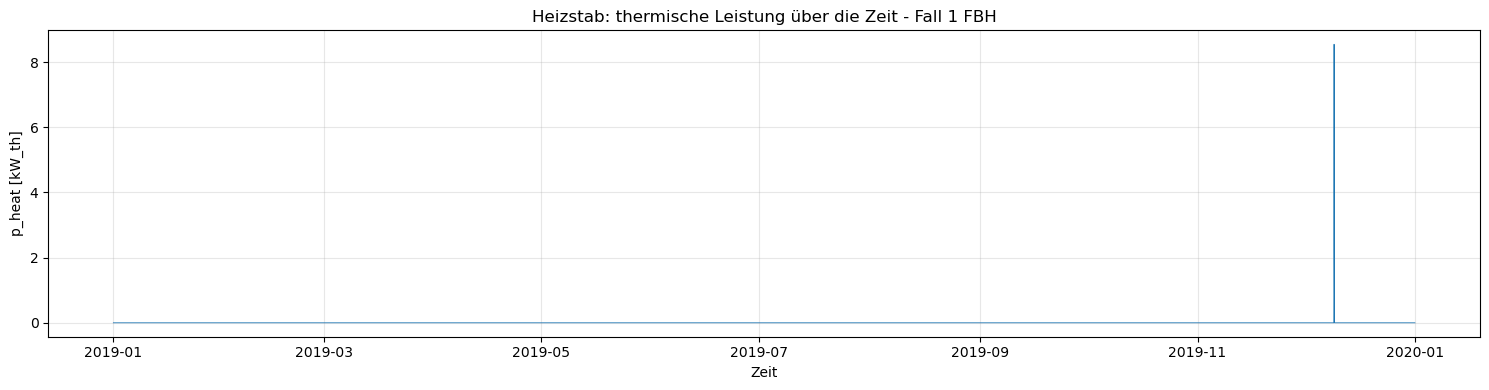

In [117]:
# ---------------------------------------
# Heizstab-Auswertung (backup_heater)
# ---------------------------------------

name = "backup_heater"

# verfügbare Keys anschauen
print("heating_elements_t keys:", list(n.heating_elements_t.keys()))

# helper: erste passende Zeitreihe nehmen
def get_ts(d, candidates):
    for c in candidates:
        if c in d:
            return d[c]
    raise KeyError(f"Keiner der Keys {candidates} in heating_elements_t vorhanden.")

# Kandidaten für "thermische Leistung" und "elektrische Leistung"
heat_key = get_ts(n.heating_elements_t, ["p_heat", "p1", "p_out", "p"])
elec_key = get_ts(n.heating_elements_t, ["p_elec", "p0", "p_in"])

# Das sind DataFrames → Spalte auswählen
p_heat = heat_key[name]
p_elec = elec_key[name]

print("\n--- Peaks ---")
print("max p_heat [kW]:", float(p_heat.max()))
print("max p_elec [kW]:", float(p_elec.max()))

# Plot
plt.figure(figsize=(15,4))
plt.plot(p_heat.index, p_heat.values, linewidth=0.6)
plt.title("Heizstab: thermische Leistung über die Zeit - Fall 1 FBH")
plt.xlabel("Zeit")
plt.ylabel("p_heat [kW_th]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### Deckungsanteile Wärmeerzeuger (WP vs. Heizstab)

In [118]:
# ============================================================
# Deckungsanteile Wärmeerzeuger (WP vs. Heizstab)
# ============================================================

# Heizstab: Jahreswärme
Q_he = float(np.nansum(p_heat.values))   # kWh_th/a

# WP: Jahreswärme (hast du schon)
Q_wp = float(Q_hp)                       # kWh_th/a

Q_total = Q_wp + Q_he

wp_share = (Q_wp / Q_total) * 100 if Q_total > 0 else np.nan
he_share = (Q_he / Q_total) * 100 if Q_total > 0 else np.nan

print("\n====================================")
print("Deckungsanteile Wärmeerzeugung")
print("====================================")
print(f"Wärmepumpe: {wp_share:.3f} %")
print(f"Heizstab:   {he_share:.3f} %")
print(f"Gesamtwärme: {Q_total:.3f} kWh_th/a")



Deckungsanteile Wärmeerzeugung
Wärmepumpe: 99.980 %
Heizstab:   0.020 %
Gesamtwärme: 67987.290 kWh_th/a


#### Strombilanz


--- Strombilanz ---
Verbrauch gesamt (HH+WP+HE+BattLaden): 36673 kWh/a
Netzbezug:                             27789 kWh/a
PV-Erzeugung:                          15355 kWh/a
Einspeisung (Export):                  -6471 kWh/a
Autarkiegrad:                          24.2 %


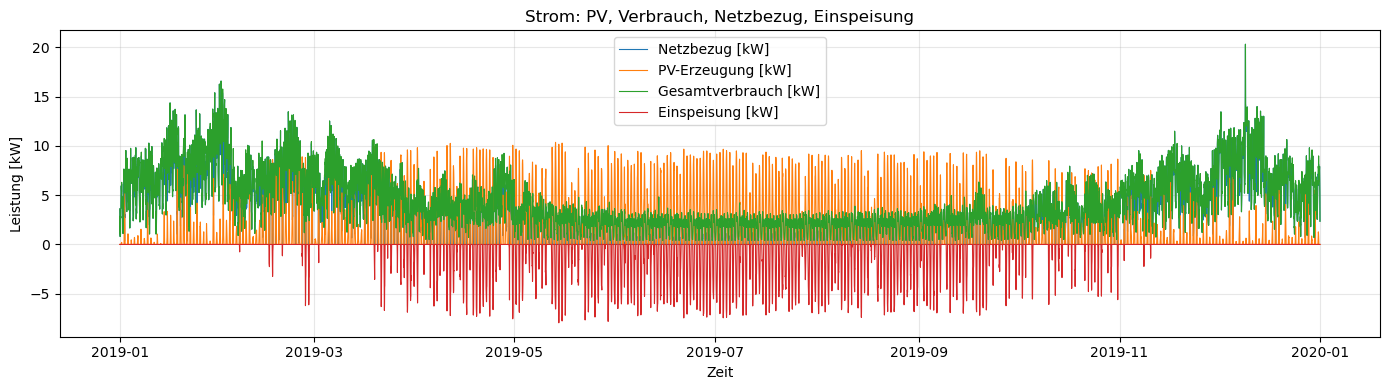

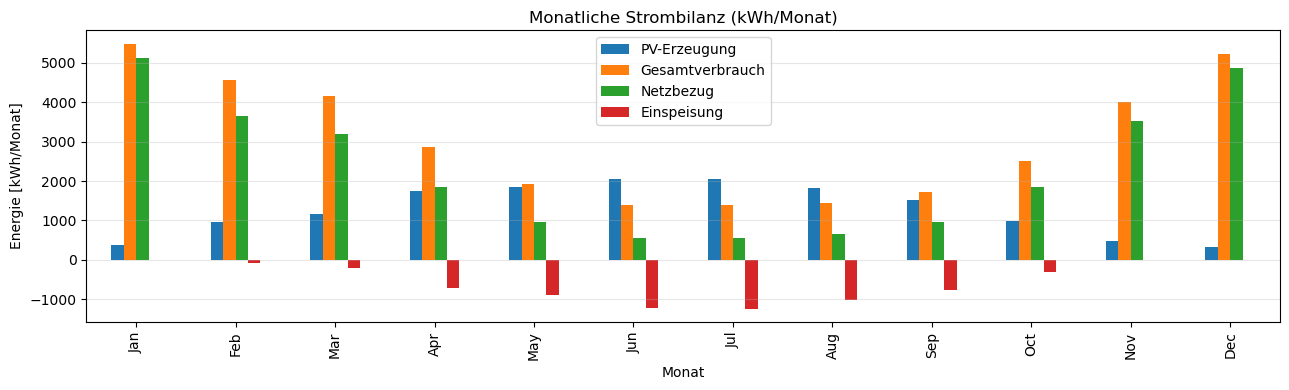

In [119]:
# ================================
#  ## - Netzbezug - PV Gen. - Einspeisung etc.
# ================================
time_index = n.snapshots

# --- 1) PV generation (kW) ---
pv_gen = n.generators_t.p["pv_generation"]     # kW, >=0

# --- 2) Grid import (kW) ---
grid_import = n.generators_t.p["grid_import"]  # kW, >=0

# --- 3) Feed-in / export (kW, make it positive) ---
if "pv_infeed" in n.generators_t.p.columns:
    export = -n.generators_t.p["pv_infeed"]    # kW, >=0
else:
    export = pd.Series(0.0, index=n.snapshots)

# --- 4) Household electric load (kW) ---
load_el = n.loads_t.p["el_demand"]  # kW
load_dhw = n.loads_t.p["el_dhw_dlhe"]

# --- 5) Heat pump electric consumption (kW) ---
hp_t = n.pnl("HeatPump")
hp_p_el = hp_t["p_elec"]["hp_mfh"]
hp_p_el_total = hp_p_el.sum(axis=1) if isinstance(hp_p_el, pd.DataFrame) else hp_p_el  # kW

# --- 6) Heating element electric consumption (kW) ---
he_t = n.pnl("HeatingElement")
he_p_el = he_t["p_elec"]["backup_heater"]
he_p_el_total = he_p_el.sum(axis=1) if isinstance(he_p_el, pd.DataFrame) else he_p_el  # kW

# --- Total electric consumption on the grid bus (kW) ---
# This is what must be covered by PV (via link), battery discharge, and grid import.
total_consumption = load_el + load_dhw + hp_p_el_total + he_p_el_total

# --- Energies (kWh) for hourly data: sum of kW values ---
E_grid = float(grid_import.sum())
E_cons = float(total_consumption.sum())
E_pv = float(pv_gen.sum())
E_exp = float(export.sum())

autarkiegrad = 1 - (E_grid / E_cons) if E_cons > 0 else np.nan

print("\n--- Strombilanz ---")
print(f"Verbrauch gesamt (HH+WP+HE+BattLaden): {E_cons:.0f} kWh/a")
print(f"Netzbezug:                             {E_grid:.0f} kWh/a")
print(f"PV-Erzeugung:                          {E_pv:.0f} kWh/a")
print(f"Einspeisung (Export):                  {E_exp:.0f} kWh/a")
print(f"Autarkiegrad:                          {autarkiegrad*100:.1f} %")

# --- Plot: power time series ---
plt.figure(figsize=(14,4))
plt.plot(time_index, grid_import.values, label="Netzbezug [kW]", linewidth=0.8)
plt.plot(time_index, pv_gen.values, label="PV-Erzeugung [kW]", linewidth=0.8)
plt.plot(time_index, total_consumption.values, label="Gesamtverbrauch [kW]", linewidth=0.8)
plt.plot(time_index, export.values, label="Einspeisung [kW]", linewidth=0.8)
plt.title("Strom: PV, Verbrauch, Netzbezug, Einspeisung")
plt.xlabel("Zeit")
plt.ylabel("Leistung [kW]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Monthly energy bars (kWh/month) ---
pv_ts   = pd.Series(pv_gen.to_numpy(), index=time_index)
cons_ts = pd.Series(total_consumption.to_numpy(), index=time_index)
imp_ts  = pd.Series(grid_import.to_numpy(), index=time_index)
exp_ts  = pd.Series(export.to_numpy(), index=time_index)

monthly = pd.DataFrame({
    "PV-Erzeugung":     pv_ts.resample("ME").sum(),
    "Gesamtverbrauch": cons_ts.resample("ME").sum(),
    "Netzbezug":       imp_ts.resample("ME").sum(),
    "Einspeisung":            exp_ts.resample("ME").sum(),
})
monthly.index = monthly.index.strftime("%b")

ax = monthly.plot(kind="bar", figsize=(13,4))
ax.set_title("Monatliche Strombilanz (kWh/Monat)")
ax.set_xlabel("Monat")
ax.set_ylabel("Energie [kWh/Monat]")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [120]:
# ============================================================
# PV-Deckung der Wärmepumpe (WP)
# ============================================================

# PV -> Hausnetz (kW) über den Link
pv_to_house = n.links_t.p0["electricity_link"]  # Leistung auf bus0-Seite (infeed -> grid), i.d.R. >=0

# Gesamtzufluss ins Hausnetz (kW): Netz + PV + Batterieentladung
total_inflow = grid_import + pv_to_house

# Anteil PV am Hausnetz (zeitabhängig)
pv_share_gridbus = (pv_to_house / total_inflow.replace(0, np.nan)).clip(0, 1).fillna(0)

# WP-Strom (kW)
wp_el = hp_p_el_total

# WP-Strom aus PV (kW) als Proxy über Quellenmix
wp_from_pv = wp_el * pv_share_gridbus

E_wp = float(wp_el.sum())
E_wp_pv = float(wp_from_pv.sum())
E_wp_grid = E_wp - E_wp_pv

print("\n--- PV-Deckung Wärmepumpe ---")
print(f"WP Strom gesamt:     {E_wp:.0f} kWh/a")
print(f"WP Strom aus PV:     {E_wp_pv:.0f} kWh/a ({(E_wp_pv/E_wp*100 if E_wp>0 else 0):.1f} %)")
print(f"WP Strom aus Netz:   {E_wp_grid:.0f} kWh/a")

# ============================================================
# Kosteneinsparung durch PV-Nutzung der Wärmepumpe
# ============================================================

strompreis_grid = grid_cost                 # €/kWh
strompreis_pv   = abs(feed_in_tariff)       # €/kWh (entgangene Einspeisung)

# Kosten, wenn WP komplett aus Netz versorgt würde
cost_wp_grid_only = E_wp * strompreis_grid

# Tatsächliche Kosten mit PV-Anteil
cost_wp_real = (
    E_wp_grid * strompreis_grid +
    E_wp_pv   * strompreis_pv
)

savings_wp_pv = cost_wp_grid_only - cost_wp_real

print("\n--- Kosteneffekt PV → Wärmepumpe ---")
print(f"Kosten WP (nur Netz):        {cost_wp_grid_only:.2f} € / a")
print(f"Kosten WP (mit PV-Anteil):   {cost_wp_real:.2f} € / a")
print(f"Ersparnis durch PV-Nutzung:  {savings_wp_pv:.2f} € / a")



--- PV-Deckung Wärmepumpe ---
WP Strom gesamt:     17499 kWh/a
WP Strom aus PV:     2269 kWh/a (13.0 %)
WP Strom aus Netz:   15230 kWh/a

--- Kosteneffekt PV → Wärmepumpe ---
Kosten WP (nur Netz):        6509.70 € / a
Kosten WP (mit PV-Anteil):   5842.08 € / a
Ersparnis durch PV-Nutzung:  667.61 € / a


#### Wärmegestehungskosten Berechnung

In [121]:
# ============================================================
# LCOH_heat_total: Raumwärme (WP+HE) + DHW (DLE)
# ============================================================

dt_h = 1.0  # Stundenauflösung

# ---------- 1) Wärmemengen (kWh_th/a) ----------
Q_space_wp = float(Q_hp)      # kWh_th/a
Q_space_he = float(Q_he)      # kWh_th/a

# DHW thermischer Bedarf (kWh_th/a) aus Lastprofil
eta_dlhe = 0.98
E_dle_total = float((n.loads_t.p["el_dhw_dlhe"] * dt_h).sum())
Q_dhw_th = E_dle_total * eta_dlhe

Q_heat_total = Q_space_wp + Q_space_he + Q_dhw_th

# ---------- 2) Strommengen der Wärmeerzeuger (kWh_el/a) ----------
# WP elektrisch
E_wp_total = float(E_hp)  # kWh_el/a

# Heizstab elektrisch: aus p_elec (kW_el) über's Jahr summieren
E_he_total = float(np.nansum(p_elec.values))  # kWh_el/a

# DLE elektrisch:Load-Zeitreihe (kW_el) -> kWh_el/a
E_dle_total = float((n.loads_t.p["el_dhw_dlhe"] * dt_h).sum())

# ---------- 3) PV-Anteile (Proxy über Mix am Grid-Bus) ----------

E_wp_pv   = float((hp_p_el_total * pv_share_gridbus).sum())
E_wp_grid = E_wp_total - E_wp_pv

E_he_pv   = float((he_p_el_total * pv_share_gridbus).sum())
E_he_grid = E_he_total - E_he_pv

# DLE hat keine eigene Komponente, aber gleiche Logik über den Bus-Mix:
dle_p_el = n.loads_t.p["el_dhw_dlhe"]
E_dle_pv   = float((dle_p_el * pv_share_gridbus).sum())
E_dle_grid = E_dle_total - E_dle_pv

# ---------- 4) Wärmerelevante CAPEX (€/a) ----------
# Wenn (noch) keine CAPEX für WP/HE/Store/DLE, bleibt das 0.
capex_heat = 0.0

# ---------- 5) Variable Wärmekosten (€/a) ----------
cost_grid = grid_cost
cost_pv   = abs(feed_in_tariff)   # Opportunitätskosten PV-Nutzung

opex_heat = (
    E_wp_grid  * cost_grid + E_wp_pv  * cost_pv +
    E_he_grid  * cost_grid + E_he_pv  * cost_pv +
    E_dle_grid * cost_grid + E_dle_pv * cost_pv
)

total_heat_costs = capex_heat + opex_heat

# ---------- 6) LCOH ----------
LCOH_heat_total = total_heat_costs / Q_heat_total if Q_heat_total > 0 else np.nan

print("\n================= HEAT-LCOH (inkl. DHW/DLE) =================")
print(f"Q_space (WP+HE): {Q_space_wp + Q_space_he:,.1f} kWh_th/a")
print(f"Q_dhw_th (DLE):  {Q_dhw_th:,.1f} kWh_th/a")
print(f"Q_heat_total:    {Q_heat_total:,.1f} kWh_th/a")
print("--------------------------------------------------------------")
print(f"E_wp_total:      {E_wp_total:,.1f} kWh_el/a (PV {E_wp_pv:,.1f} | Grid {E_wp_grid:,.1f})")
print(f"E_he_total:      {E_he_total:,.1f} kWh_el/a (PV {E_he_pv:,.1f} | Grid {E_he_grid:,.1f})")
print(f"E_dle_total:     {E_dle_total:,.1f} kWh_el/a (PV {E_dle_pv:,.1f} | Grid {E_dle_grid:,.1f})")
print("--------------------------------------------------------------")
print(f"CAPEX_heat:      {capex_heat:,.2f} € / a")
print(f"OPEX_heat:       {opex_heat:,.2f} € / a")
print(f"TOTAL_heat:      {total_heat_costs:,.2f} € / a")
print(f"LCOH_heat_total: {LCOH_heat_total:.4f} € / kWh_th")
print("==============================================================\n")



# ============================================================
# 2) SYSTEMKOSTEN GESAMT (INFO): inkl. Nutzerstrom etc.
#    -> NICHT für LCOH, nur report
# ============================================================

system_cost_total = float(n.objective)  # was dein Optimierer minimiert
system_capex_total = float(n.statistics.capex().sum())
system_opex_total  = float(n.statistics.opex().sum())

print("\n================= SYSTEMKOSTEN (INFO) =================")
print(f"System TOTAL (objective): {system_cost_total:,.2f} € / a")
print(f"System CAPEX:            {system_capex_total:,.2f} € / a")
print(f"System OPEX:             {system_opex_total:,.2f} € / a")
print("=======================================================\n")



================= HEAT-LCOH (inkl. DHW/DLE) =================
Q_space (WP+HE): 67,987.3 kWh_th/a
Q_dhw_th (DLE):  7,016.7 kWh_th/a
Q_heat_total:    75,004.0 kWh_th/a
--------------------------------------------------------------
E_wp_total:      17,499.2 kWh_el/a (PV 2,269.3 | Grid 15,229.9)
E_he_total:      14.3 kWh_el/a (PV 0.0 | Grid 14.3)
E_dle_total:     7,159.9 kWh_el/a (PV 2,548.3 | Grid 4,611.6)
--------------------------------------------------------------
CAPEX_heat:      0.00 € / a
OPEX_heat:       7,761.18 € / a
TOTAL_heat:      7,761.18 € / a
LCOH_heat_total: 0.1035 € / kWh_th


================= SYSTEMKOSTEN (INFO) =================
System TOTAL (objective): 9,834.06 € / a
System CAPEX:            581.17 € / a
System OPEX:             9,834.06 € / a



### Ergebnisse Speichern

In [122]:
# # ============================================================
# # Ergebnis-CSV - auskommentiert für Abgabe
# # ============================================================
#
# scenario_id = f"{lastgang_version}__Tv{int(T_vorlauf)}__{'HK' if use_radiators else 'FBH'}"
# # z.B. "ist_zst__Tv55__HK"
#
# results_row = {
#     # =========================
#     # Meta
#     # =========================
#     "scenario_id": scenario_id,
#     "lastgang_version": lastgang_version,
#     "lastgang_file": str(lastgang_file),
#     "use_radiators": bool(use_radiators),
#     "T_vorlauf_C": float(T_vorlauf),
#
#     # =========================
#     # Wärme (kWh_th/a)
#     # =========================
#     "Q_hp_kWh_th": float(Q_hp),                    # Raumwärme WP
#     "Q_he_kWh_th": float(Q_he),                    # Raumwärme Heizstab
#     "Q_space_kWh_th": float(Q_hp + Q_he),          # Raumwärme gesamt
#     "Q_dhw_kWh_th": float(Q_dhw_th),               # DHW thermisch (über DLE)
#     "Q_heat_total_kWh_th": float(Q_heat_total),    # Raumwärme + DHW
#
#     # =========================
#     # Wärmepumpe
#     # =========================
#     "JAZ_wp": float(JAZ_hp),
#     "WP_Nennleistung_kW": float(HP_power),
#     "WP_Deckungsanteil_pct": float(wp_share),
#     "E_wp_kWh_el": float(E_hp),                    # WP Strom gesamt
#
#     # =========================
#     # Heizstab
#     # =========================
#     "HE_Nennleistung_kW": float(HE_power),
#     "HE_Deckungsanteil_pct": float(he_share),
#     "E_he_kWh_el": float(E_he_total),              # Heizstab Strom gesamt
#
#     # =========================
#     # DLE / DHW
#     # =========================
#     "eta_dlhe": float(eta_dlhe),
#     "E_dle_kWh_el": float(E_dle_total),            # DLE Strom gesamt
#
#     # =========================
#     # Strombilanz (kWh_el/a)
#     # =========================
#     "grid_import_kWh": float(E_grid),
#     "pv_generation_kWh": float(E_pv),
#     "pv_export_kWh": float(E_exp),
#     "electric_consumption_kWh": float(E_cons),
#     "autarkiegrad_pct": float(autarkiegrad * 100),
#
#     # =========================
#     # Stromaufteilung (Proxy) PV vs Grid
#     # =========================
#     # WP
#     "WP_Strom_PV_kWh": float(E_wp_pv),
#     "WP_Strom_Netz_kWh": float(E_wp_grid),
#     "WP_PV_Anteil_pct": float(E_wp_pv / E_hp * 100 if E_hp > 0 else 0),
#
#     # HE
#     "HE_Strom_PV_kWh": float(E_he_pv),
#     "HE_Strom_Netz_kWh": float(E_he_grid),
#     "HE_PV_Anteil_pct": float(E_he_pv / E_he_total * 100 if E_he_total > 0 else 0),
#
#     # DLE
#     "DLE_Strom_PV_kWh": float(E_dle_pv),
#     "DLE_Strom_Netz_kWh": float(E_dle_grid),
#     "DLE_PV_Anteil_pct": float(E_dle_pv / E_dle_total * 100 if E_dle_total > 0 else 0),
#
#     # =========================
#     # Heat-only Kosten + LCOH
#     # =========================
#     "Heat_opex_EUR_per_a": float(opex_heat),
#     "Heat_capex_EUR_per_a": float(capex_heat),
#     "Heat_cost_total_EUR_per_a": float(total_heat_costs),
#     "LCOH_heat_EUR_per_kWh_th": float(LCOH_heat_total),
#
#     # =========================
#     # Systemkosten (Info: enthält auch Nutzerstrom etc.)
#     # =========================
#     "Total_costs_EUR_per_a": float(system_cost_total),
#     "CAPEX_EUR_per_a": float(system_capex_total),
#     "OPEX_EUR_per_a": float(system_opex_total),
#     # =========================
#     # PV-Effekt (Info/Proxy)
#     # =========================
#     "WP_Kostenersparnis_durch_PV_EUR_per_a": float(savings_wp_pv),
# }
#
#
# BASE_DIR = Path.cwd()
# results_dir = BASE_DIR / "Output" / "sensitivity_runs"
# results_dir.mkdir(parents=True, exist_ok=True)
#
# results_path = results_dir / f"results_{scenario_id}_DLE.csv"
# pd.DataFrame([results_row]).to_csv(results_path, index=False)
#
# print(f"\nNeue Datei pro Run gespeichert in:\n{results_path.resolve()}")